In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealtman2019/ibm-transactions-for-anti-money-laundering-aml")

print("Path to dataset files:", path)

100%|██████████| 7.61G/7.61G [01:22<00:00, 99.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8


In [2]:
import os
os.listdir(path)

['HI-Small_Patterns.txt',
 'LI-Large_Trans.csv',
 'LI-Medium_accounts.csv',
 'LI-Small_Patterns.txt',
 'HI-Medium_accounts.csv',
 'LI-Medium_Trans.csv',
 'LI-Medium_Patterns.txt',
 'HI-Large_Trans.csv',
 'HI-Medium_Patterns.txt',
 'HI-Small_Trans.csv',
 'LI-Large_accounts.csv',
 'HI-Small_accounts.csv',
 'LI-Large_Patterns.txt',
 'LI-Small_Trans.csv',
 'HI-Large_accounts.csv',
 'HI-Large_Patterns.txt',
 'HI-Medium_Trans.csv',
 'LI-Small_accounts.csv']

In [5]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum

In [ ]:
# df_transactions = pd.read_csv(path + "/HI-Medium_Trans.csv",
#                               dtype = {'Is Laundering': 'bool',
#                               'From Bank': 'int32',
#                               'To Bank': 'int32',
#                               'Amount Received': 'category',
#                               'Amount Paid': 'category',
#                               'Timestamp': 'category',
#                               'Payment Currency': 'category',
#                               'Receiving Currency': 'category',
#                               'Payment Format': 'category'},
#                               low_memory = False)
# display(df_transactions.head(5))
# print(df_transactions.info())

In [4]:
trans_path = path + "/HI-Medium_Trans.csv"
accounts_path = path + "/HI-Medium_accounts.csv"
patterns_path = path + "/HI-Medium_Patterns.txt"

In [ ]:
spark = SparkSession.builder \
    .appName("IBM_AML_EDA") \
    .getOrCreate()

df = spark.read.csv(trans_path, header=True, inferSchema=True)

df.printSchema()
df.show(5)

root
 |-- Timestamp: string (nullable = true)
 |-- From Bank: integer (nullable = true)
 |-- Account2: string (nullable = true)
 |-- To Bank: integer (nullable = true)
 |-- Account4: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: integer (nullable = true)

+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|       Timestamp|From Bank| Account2|To Bank| Account4|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+----------------+---------+---------+-------+---------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022/09/01 00:17|       20|800104D70|     20|800104D70|     

In [ ]:
df.groupBy("Is Laundering").count().show()

+-------------+--------+
|Is Laundering|   count|
+-------------+--------+
|            1|   35230|
|            0|31863008|
+-------------+--------+



nhận xét: dữ liệu mất cân bằng nặng(imbalance), tỷ lệ giao dịch gian lận 0.1%

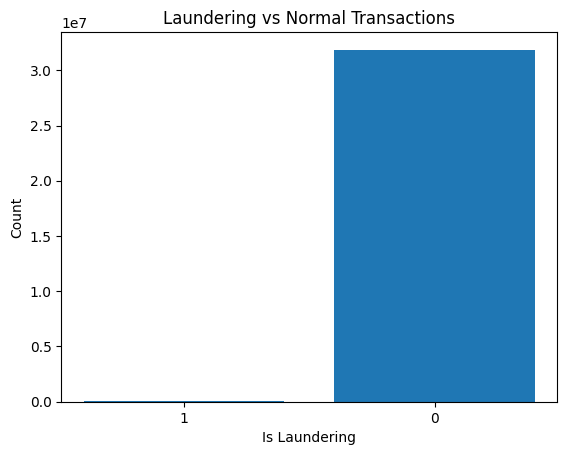

In [ ]:
pdf = df.groupBy("Is Laundering").count().toPandas()

plt.bar(pdf["Is Laundering"].astype(str), pdf["count"])
plt.title("Laundering vs Normal Transactions")
plt.xlabel("Is Laundering")
plt.ylabel("Count")
plt.show()

**Transaction Amount Distribution**

In [ ]:
df = df.withColumn("amount_paid", col("Amount Paid").cast("double"))

In [ ]:
sample = df.sample(fraction=0.01, seed=42).toPandas()

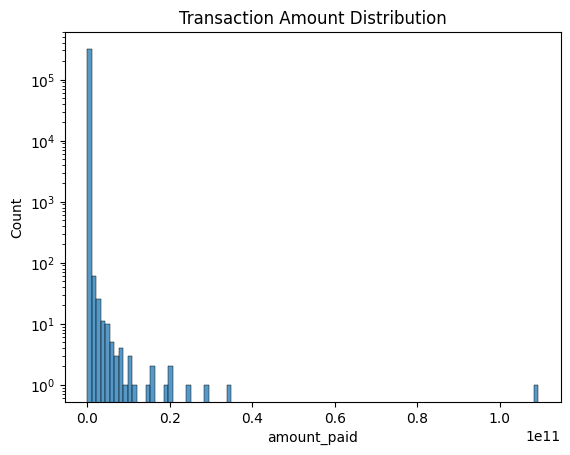

In [ ]:
sns.histplot(sample["amount_paid"], bins=100)
plt.yscale("log")
plt.title("Transaction Amount Distribution")
plt.show()

**Currency Distribution**

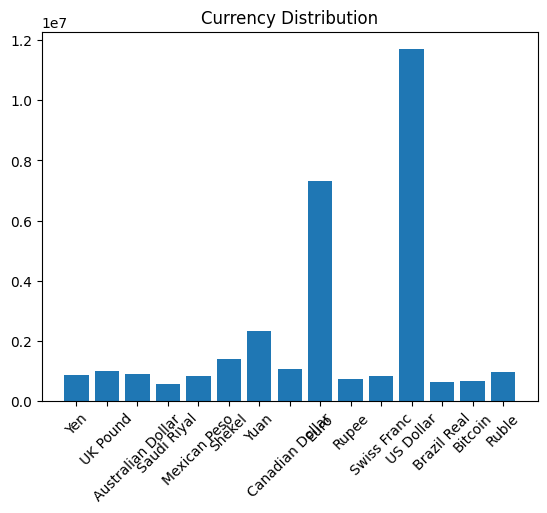

In [ ]:
currency_dist = df.groupBy("Payment Currency").count()
pdf = currency_dist.toPandas()

plt.bar(pdf["Payment Currency"], pdf["count"])
plt.title("Currency Distribution")
plt.xticks(rotation=45)
plt.show()

**Transactions per Account**

In [ ]:
tx_per_account = df.groupBy("Account2").agg(
    count("*").alias("num_tx")
)

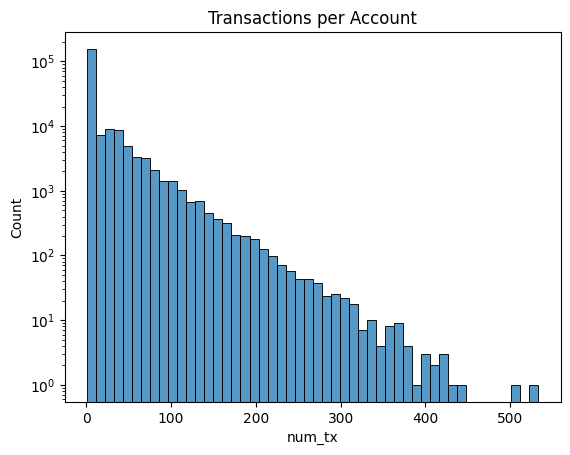

In [ ]:
pdf = tx_per_account.sample(fraction=0.1).toPandas()

sns.histplot(pdf["num_tx"], bins=50)
plt.yscale("log")
plt.title("Transactions per Account")
plt.show()

**Unique Account**

In [ ]:
from_accounts = df.select("Account2").distinct().count()
to_accounts = df.select("Account4").distinct().count()

print("unique senders:", from_accounts)
print("unique receivers:", to_accounts)

unique senders: 2013627
unique receivers: 1689925


**Bank-level Network**

In [ ]:
bank_edges = df.groupBy("From Bank", "To Bank").count()

pdf = bank_edges.sample(fraction=0.02).toPandas()

In [ ]:
# G = nx.from_pandas_edgelist(
#     pdf,
#     source="From Bank",
#     target="To Bank"
# )

# nx.draw(G, node_size=100)
# plt.title("Interbank Network")
# plt.show()

**Transaction Graph Sample**

In [ ]:
sample = df.sample(fraction=0.0001).toPandas()

G = nx.from_pandas_edgelist(
    sample,
    source="Account2",
    target="Account4",
    create_using=nx.DiGraph()
)

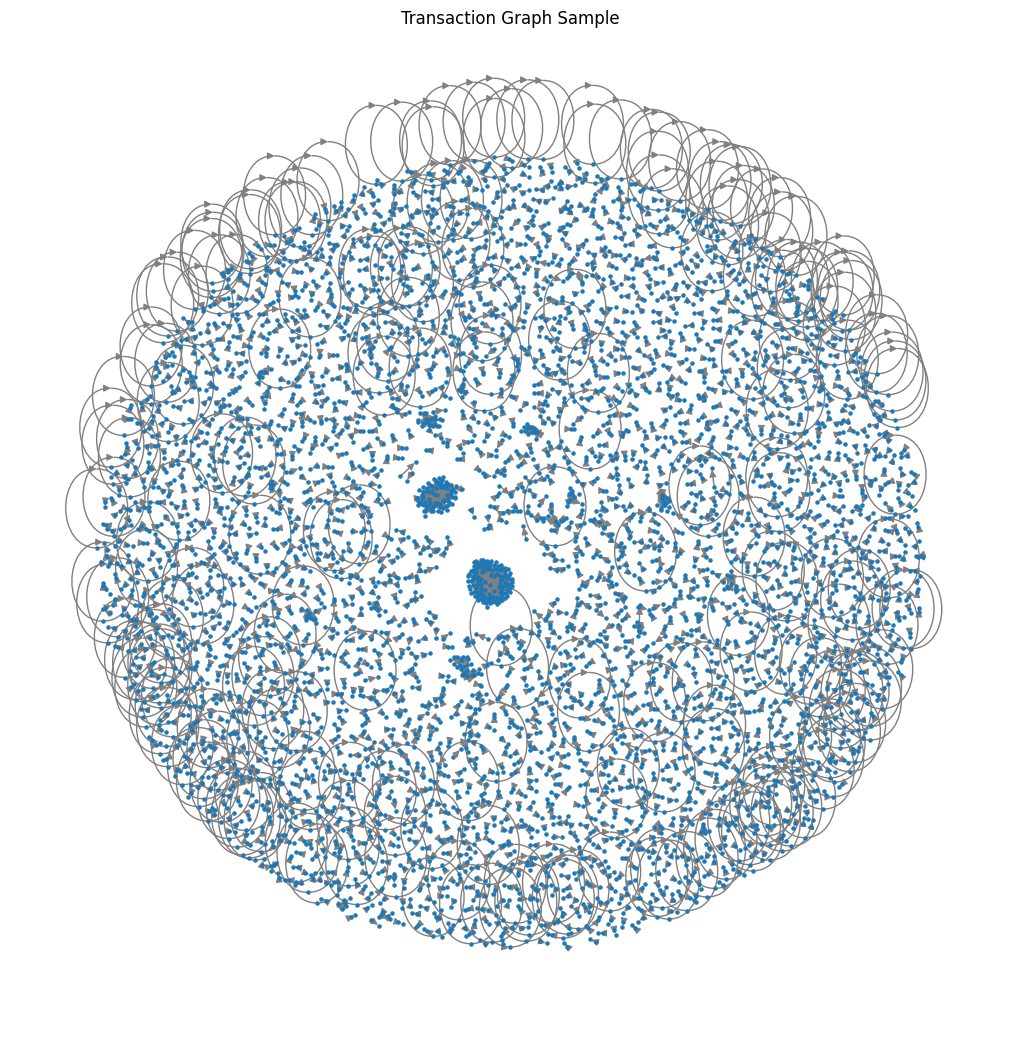

In [ ]:
plt.figure(figsize=(10,10))
nx.draw(G, node_size=5, edge_color="gray")
plt.title("Transaction Graph Sample")
plt.show()

In [ ]:
degree_dict = dict(G.degree())
threshold = np.percentile(list(degree_dict.values()), 95)

hubs = [n for n,d in degree_dict.items() if d > threshold]

In [ ]:
cycles = list(nx.simple_cycles(G))
print("num cycles:", len(cycles))

num cycles: 268


In [ ]:
pos = nx.spring_layout(G, k=0.15, iterations=20)

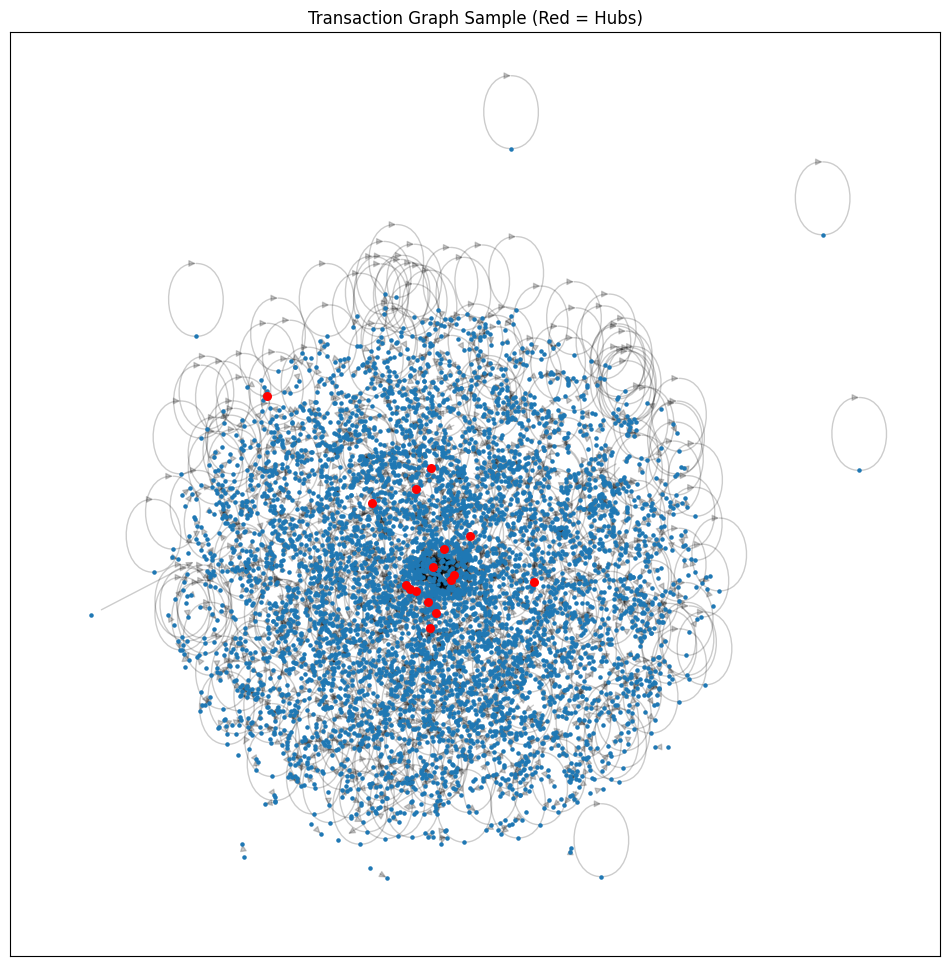

In [ ]:
plt.figure(figsize=(12,12))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=5
    # node_color="lightblue"
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=hubs,
    node_size=30,
    node_color="red"
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title("Transaction Graph Sample (Red = Hubs)")
plt.show()

In [ ]:
loop_edges = []

for cycle in cycles:
    for i in range(len(cycle)):
        loop_edges.append((cycle[i], cycle[(i+1)%len(cycle)]))

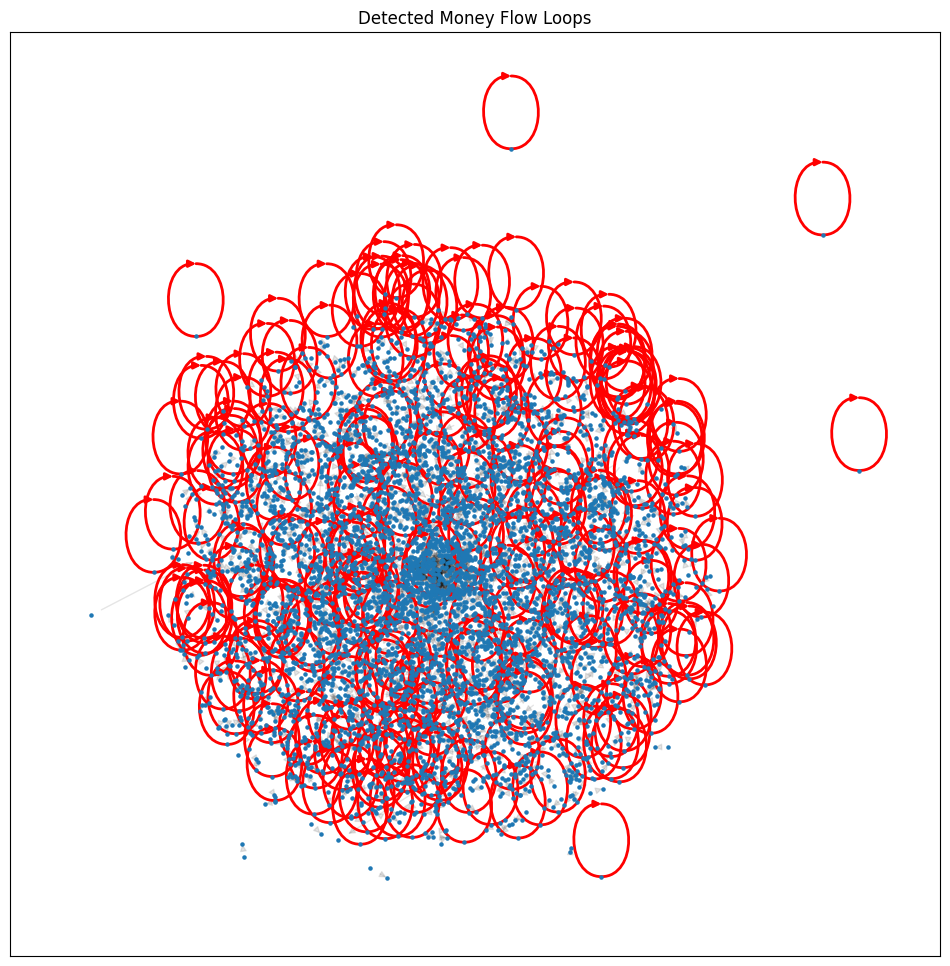

In [ ]:
plt.figure(figsize=(12,12))
nx.draw_networkx_nodes(G, pos, node_size=5)
nx.draw_networkx_edges(G, pos, alpha=0.1)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=loop_edges,
    edge_color="red",
    width=2
)

plt.title("Detected Money Flow Loops")
plt.show()

Tìm thấy 8 loại hình gian lận chính:
STACK, CYCLE, FAN-IN, GATHER-SCATTER, BIPARTITE, FAN-OUT, SCATTER-GATHER, RANDOM


/tmp/ipykernel_458/4217606841.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_patterns, y='Pattern_Category', order=df_patterns['Pattern_Category'].value_counts().index, palette='viridis')


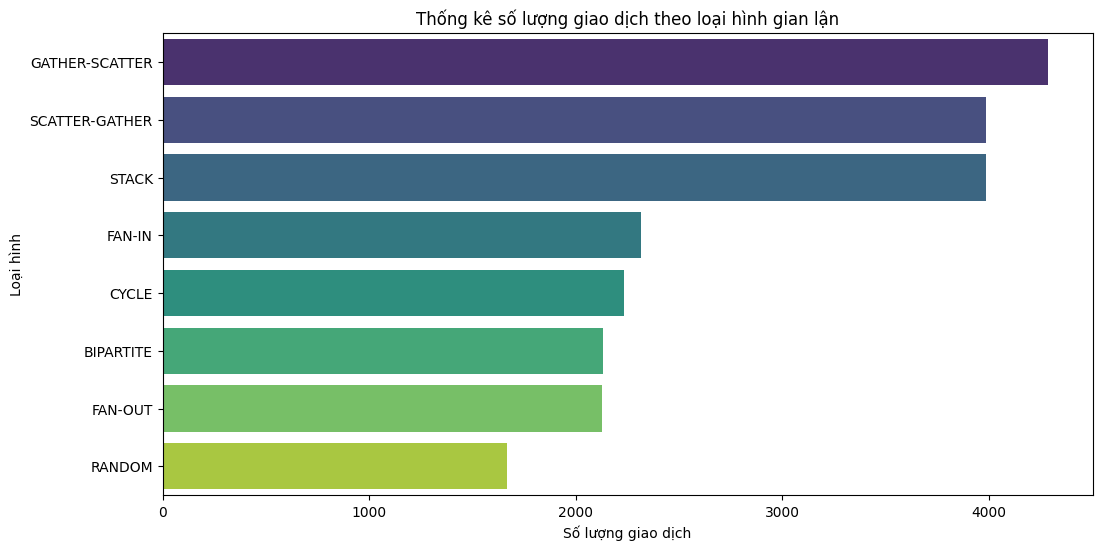

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

pattern_types = []
raw_data = []

# Tên cột cho dữ liệu giao dịch
column_names = [
    'Timestamp', 'From_Bank', 'From_Account', 'To_Bank', 'To_Account',
    'Amount_Received', 'Currency_Received', 'Amount_Paid', 'Currency_Paid',
    'Payment_Format', 'Is_Laundering'
]

current_type = None

try:
    with open(patterns_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue

            # Tìm dòng bắt đầu loại gian lận
            if line.startswith("BEGIN LAUNDERING ATTEMPT -"):
                # Trích xuất loại gian lận (ví dụ: FAN-IN, CYCLE)
                match = re.search(r"BEGIN LAUNDERING ATTEMPT - ([^:]+)", line)
                if match:
                    current_type = match.group(1).strip()
                continue

            # Bỏ qua dòng kết thúc
            if line.startswith("END LAUNDERING ATTEMPT"):
                continue

            # Đọc dữ liệu giao dịch
            parts = line.split(',')
            if len(parts) >= 10 and current_type:
                raw_data.append(parts + [current_type])

    # Tạo DataFrame
    df_patterns = pd.DataFrame(raw_data, columns=column_names + ['Pattern_Category'])

    unique_patterns = df_patterns['Pattern_Category'].unique()
    print(f"Tìm thấy {len(unique_patterns)} loại hình gian lận chính:")
    print(", ".join(unique_patterns))

    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_patterns, y='Pattern_Category', order=df_patterns['Pattern_Category'].value_counts().index, palette='viridis')
    plt.title("Thống kê số lượng giao dịch theo loại hình gian lận")
    plt.xlabel("Số lượng giao dịch")
    plt.ylabel("Loại hình")
    plt.show()

except Exception as e:
    print(f"Lỗi xử lý file: {e}")


============================== LOẠI GIAN LẬN: STACK ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 05:14,00952,8139F54E0,0111632,8062C56E0,5331.44,US Dollar,5331.44,US Dollar,ACH,1
1,2022/09/03 13:09,0111632,8062C56E0,008456,81363F620,5602.59,US Dollar,5602.59,US Dollar,ACH,1
2,2022/09/01 07:40,0118693,823D5EB90,013729,801CF2E60,1400.54,US Dollar,1400.54,US Dollar,ACH,1
3,2022/09/01 14:19,013729,801CF2E60,0123621,81A7090F0,1467.94,US Dollar,1467.94,US Dollar,ACH,1
4,2022/09/02 12:40,0024750,81363F410,0213834,808757B00,16898.29,US Dollar,16898.29,US Dollar,ACH,1
5,2022/09/03 06:34,0213834,808757B00,000,800073EF0,17607.19,US Dollar,17607.19,US Dollar,ACH,1


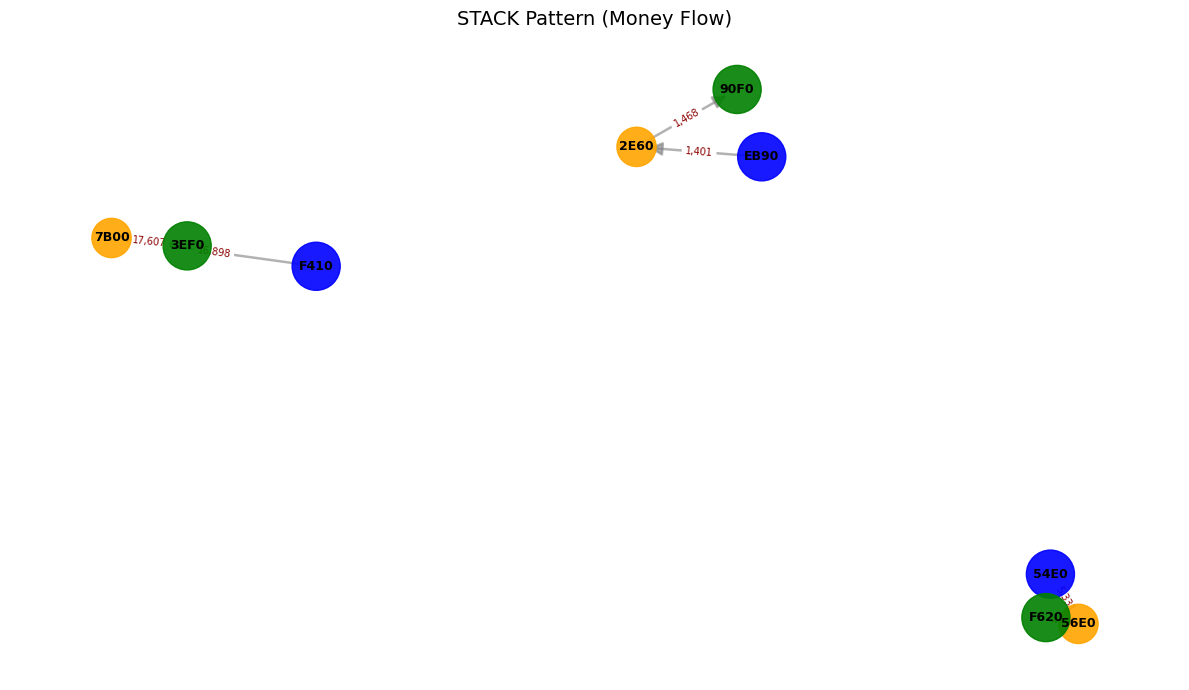


============================== LOẠI GIAN LẬN: CYCLE ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 00:19,0134266,814167590,0036925,810E343A0,132713.46,Yuan,132713.46,Yuan,ACH,1
1,2022/09/01 19:35,0036925,810E343A0,0119211,814AB4F60,18264.20,US Dollar,18264.20,US Dollar,ACH,1
2,2022/09/02 02:58,0119211,814AB4F60,0132965,81B88A230,14567.69,Euro,14567.69,Euro,ACH,1
3,2022/09/02 18:02,0132965,81B88A230,0137089,810C71940,114329.26,Yuan,114329.26,Yuan,ACH,1
4,2022/09/03 07:16,0137089,810C71940,0216618,81D5302D0,14567.69,Euro,14567.69,Euro,ACH,1
5,2022/09/03 11:39,0216618,81D5302D0,0024083,81836B520,13629.75,Euro,13629.75,Euro,ACH,1
6,2022/09/03 12:04,0024083,81836B520,0038110,81B868730,97481.96,Yuan,97481.96,Yuan,ACH,1
7,2022/09/04 07:27,0038110,81B868730,0225015,81C6EA460,14054.71,US Dollar,14054.71,US Dollar,ACH,1
8,2022/09/04 08:38,0225015,81C6EA460,018112,8045CC910,13718.22,US Dollar,13718.22,US Dollar,ACH,1
9,2022/09/05 13:23,018112,8045CC910,007818,8037732C0,12908.33,US Dollar,12908.33,US Dollar,ACH,1


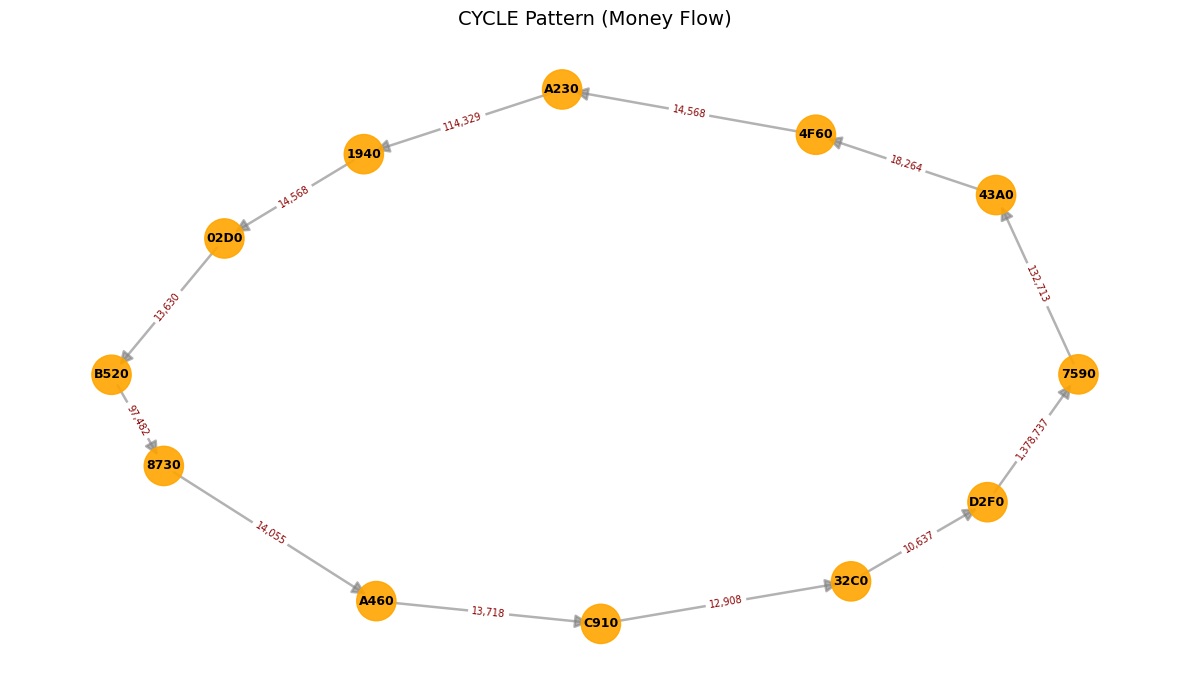


============================== LOẠI GIAN LẬN: FAN-IN ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 00:25,0266915,81C3CD2E0,0266946,81A4AFE20,1155546.44,Ruble,1155546.44,Ruble,ACH,1
1,2022/09/01 03:18,0174634,81C5B2AB0,0266946,81A4AFE20,1104862.69,Ruble,1104862.69,Ruble,ACH,1
2,2022/09/01 05:28,029,81A4AF9E0,0266946,81A4AFE20,1392590.03,Ruble,1392590.03,Ruble,ACH,1
3,2022/09/02 02:31,026,81A4B0100,0266946,81A4AFE20,118642.14,Ruble,118642.14,Ruble,ACH,1
4,2022/09/02 09:35,0275027,81C5B34A0,0266946,81A4AFE20,763621.80,Ruble,763621.80,Ruble,ACH,1
5,2022/09/04 17:13,015,81C5B2A60,0266946,81A4AFE20,19082.30,Ruble,19082.30,Ruble,ACH,1
6,2022/09/05 12:09,026,81C5B2870,0266946,81A4AFE20,1306642.42,Ruble,1306642.42,Ruble,ACH,1
7,2022/09/05 16:09,0072043,81A4AFE70,0266946,81A4AFE20,1409305.96,Ruble,1409305.96,Ruble,ACH,1
8,2022/09/05 17:52,0175986,81C5B3BD0,0266946,81A4AFE20,324388.99,Ruble,324388.99,Ruble,ACH,1


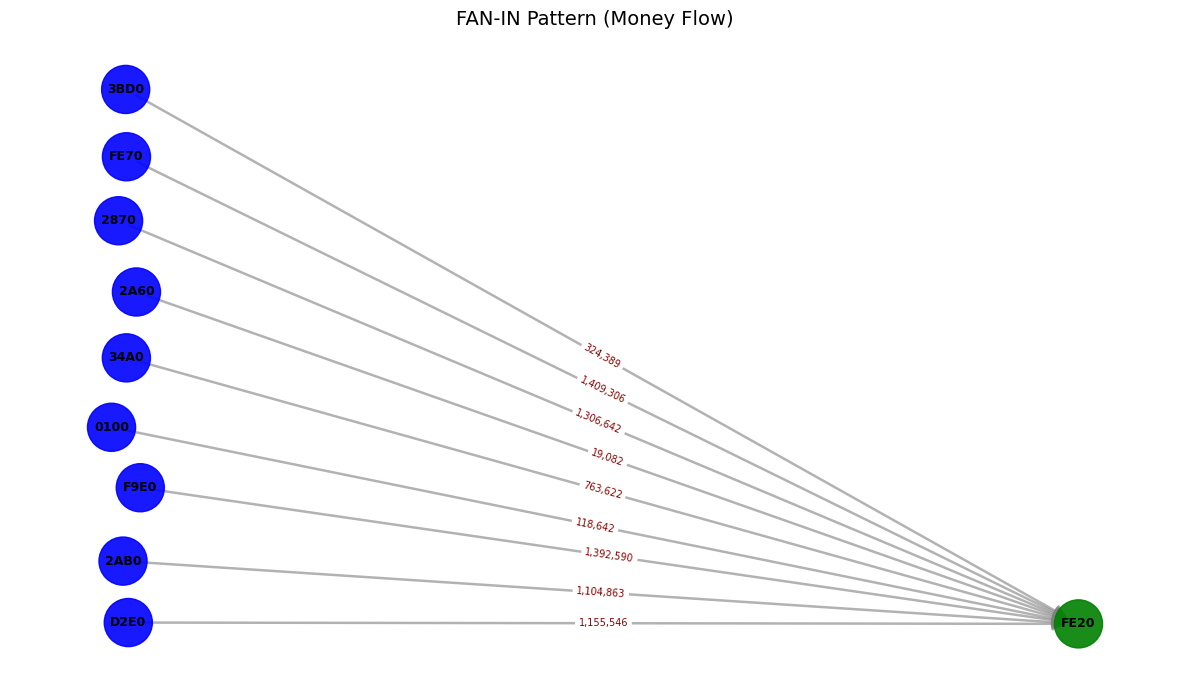


============================== LOẠI GIAN LẬN: GATHER-SCATTER ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 00:10,0125344,810E70660,0214872,80651B5B0,11226.65,Euro,11226.65,Euro,ACH,1
1,2022/09/02 01:51,0131458,80DCE6DB0,0214872,80651B5B0,11440.73,Euro,11440.73,Euro,ACH,1
2,2022/09/02 07:27,0212859,808ED0920,0214872,80651B5B0,2317.16,Euro,2317.16,Euro,ACH,1
3,2022/09/02 09:19,0277109,81D3BE660,0214872,80651B5B0,2710.20,Euro,2710.20,Euro,ACH,1
4,2022/09/02 10:11,0026682,80C354EE0,0214872,80651B5B0,2937.53,Euro,2937.53,Euro,ACH,1
5,2022/09/03 16:22,0220538,81C92D9B0,0214872,80651B5B0,333.95,Euro,333.95,Euro,ACH,1
6,2022/09/05 07:22,01924,8005613C0,0214872,80651B5B0,10461.73,Euro,10461.73,Euro,ACH,1
7,2022/09/06 16:20,0123117,812199E60,0214872,80651B5B0,5591.22,Euro,5591.22,Euro,ACH,1
8,2022/09/06 14:58,0214872,80651B5B0,012582,805373C30,5857.92,US Dollar,5857.92,US Dollar,ACH,1
9,2022/09/06 15:20,0214872,80651B5B0,0131185,80D581110,14730.63,US Dollar,14730.63,US Dollar,ACH,1


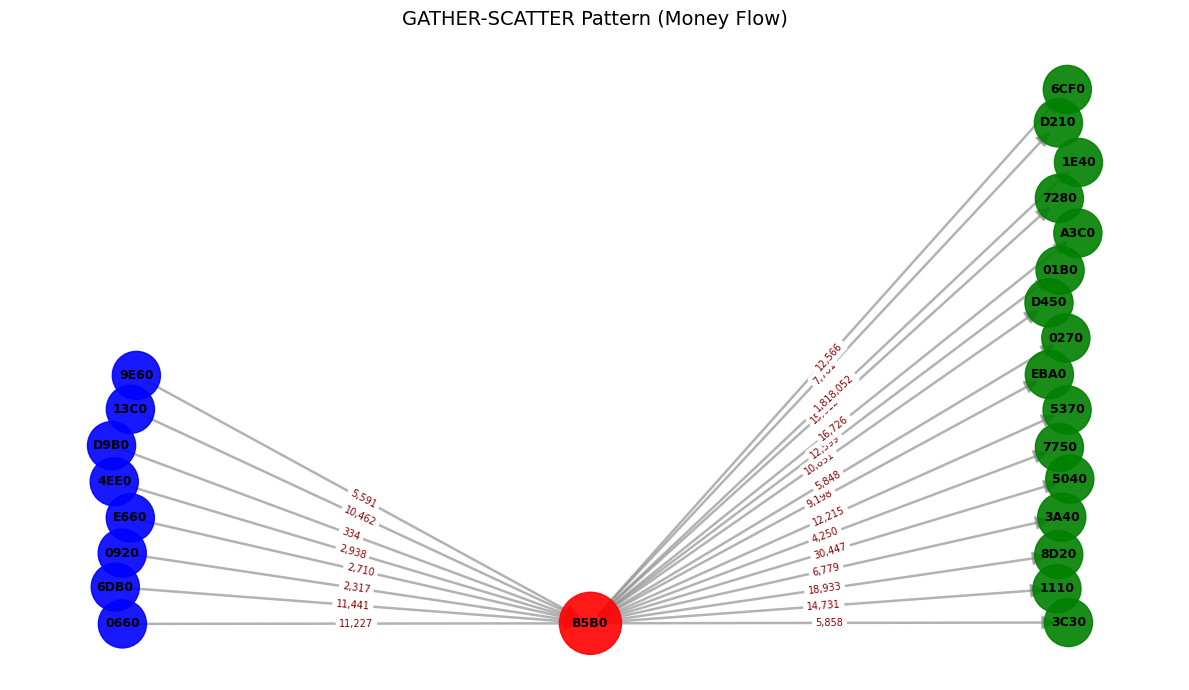


============================== LOẠI GIAN LẬN: BIPARTITE ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 19:51,01213,80084C830,00519,800A985D0,15206.94,Euro,15206.94,Euro,ACH,1
1,2022/09/01 18:16,01553,800BB9C30,01347,80074BD60,2266.59,Euro,2266.59,Euro,ACH,1
2,2022/09/03 14:40,02776,800D01610,00718,800496D30,13525.85,US Dollar,13525.85,US Dollar,ACH,1
3,2022/09/02 00:08,00357,8002FBC20,011054,800C1C130,13065.12,Euro,13065.12,Euro,ACH,1
4,2022/09/03 06:11,02310,800279EA0,01213,800509260,8707.67,Euro,8707.67,Euro,ACH,1
5,2022/09/03 18:06,01553,80085E8B0,011081,8007E1A10,17618.21,US Dollar,17618.21,US Dollar,ACH,1
6,2022/09/02 19:32,00867,80062BE20,021,8006A5050,118150.60,Yuan,118150.60,Yuan,ACH,1
7,2022/09/01 12:47,001148,80074D820,021617,800DF8C10,5117406.94,Euro,5117406.94,Euro,ACH,1


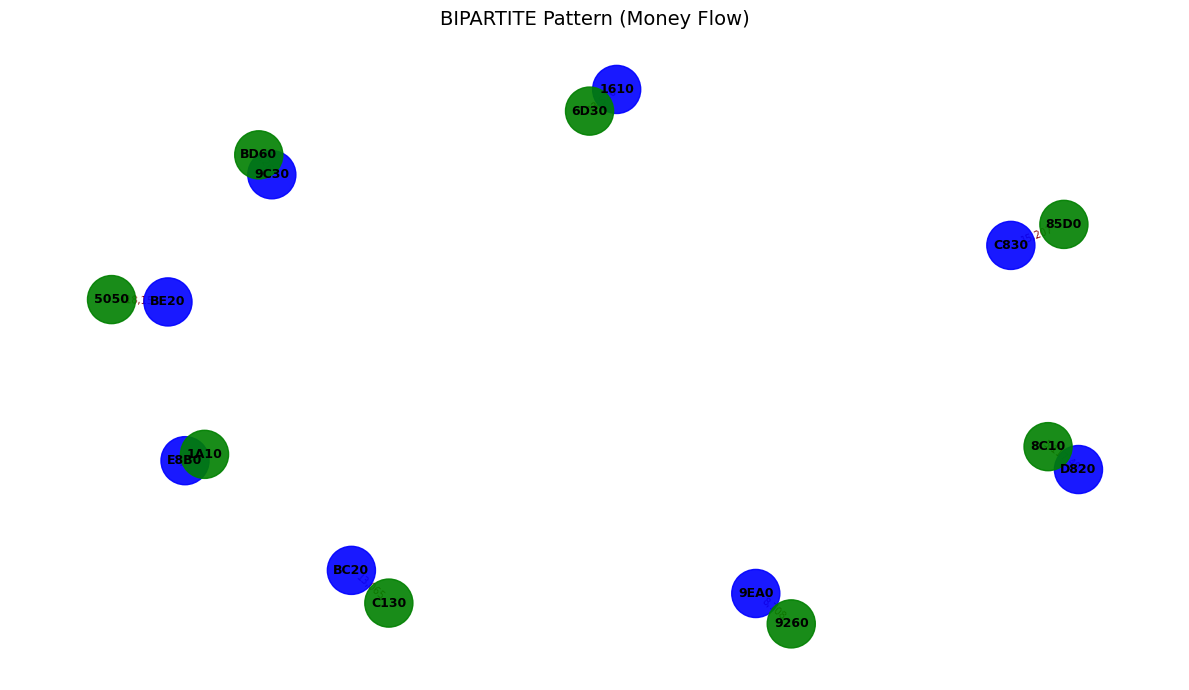


============================== LOẠI GIAN LẬN: FAN-OUT ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 00:52,018824,8057DE230,0224668,80EF3EEE0,16264.08,Yuan,16264.08,Yuan,ACH,1
1,2022/09/01 09:10,018824,8057DE230,02310,802850070,5749.51,US Dollar,5749.51,US Dollar,ACH,1
2,2022/09/02 13:20,018824,8057DE230,011054,80128D900,21157441.34,Euro,21157441.34,Euro,ACH,1
3,2022/09/03 02:08,018824,8057DE230,0115290,815EEA7F0,1819.85,US Dollar,1819.85,US Dollar,ACH,1
4,2022/09/04 00:02,018824,8057DE230,0216924,808C676A0,10269.15,Euro,10269.15,Euro,ACH,1
5,2022/09/04 19:42,018824,8057DE230,000,8006699C0,14276.13,US Dollar,14276.13,US Dollar,ACH,1
6,2022/09/05 04:06,018824,8057DE230,025644,8116C4770,10813.94,US Dollar,10813.94,US Dollar,ACH,1


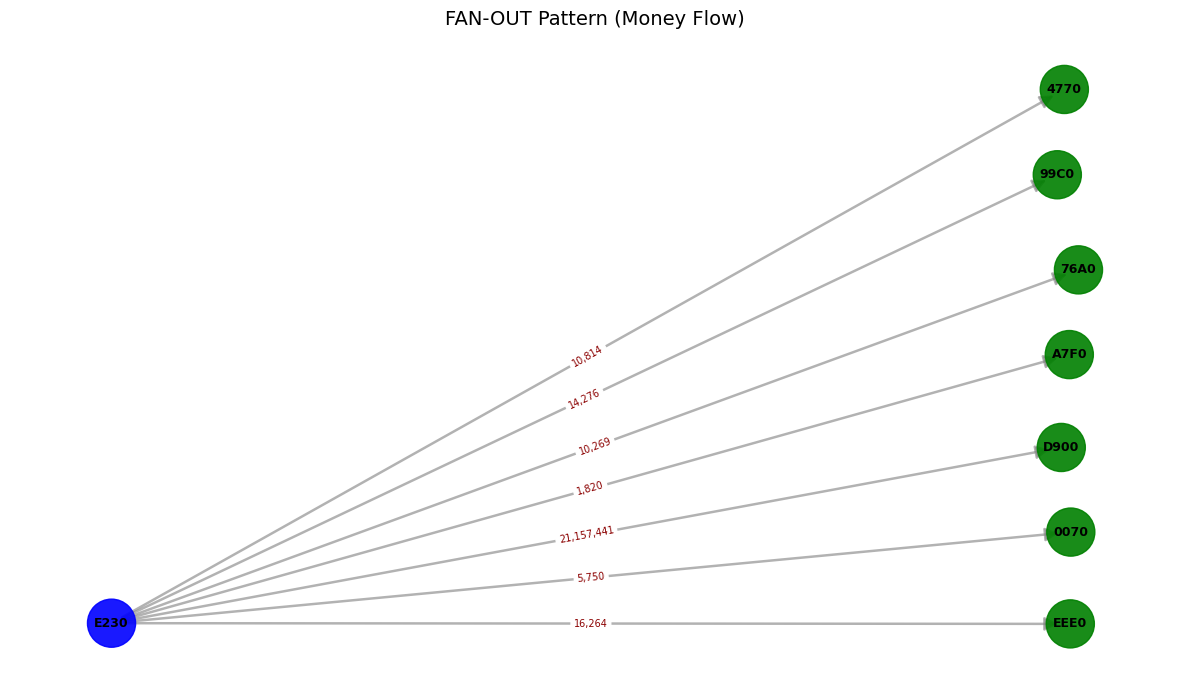


============================== LOẠI GIAN LẬN: SCATTER-GATHER ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 02:39,015598,8022C7240,023375,801A1CEC0,1377.20,Euro,1377.20,Euro,ACH,1
1,2022/09/06 12:38,023375,801A1CEC0,011054,80120B860,1313.95,Euro,1313.95,Euro,ACH,1
2,2022/09/03 19:47,015598,8022C7240,012,80023E3F0,12170.84,Euro,12170.84,Euro,ACH,1
3,2022/09/06 13:43,012,80023E3F0,011054,80120B860,11883.93,Euro,11883.93,Euro,ACH,1
4,2022/09/05 16:37,015598,8022C7240,011798,8019EC9C0,14193.15,US Dollar,14193.15,US Dollar,ACH,1
5,2022/09/07 01:10,011798,8019EC9C0,011054,80120B860,12047.76,Euro,12047.76,Euro,ACH,1
6,2022/09/06 10:50,015598,8022C7240,00519,800A69E80,4297.96,Euro,4297.96,Euro,ACH,1
7,2022/09/07 02:32,00519,800A69E80,011054,80120B860,4105.47,Euro,4105.47,Euro,ACH,1


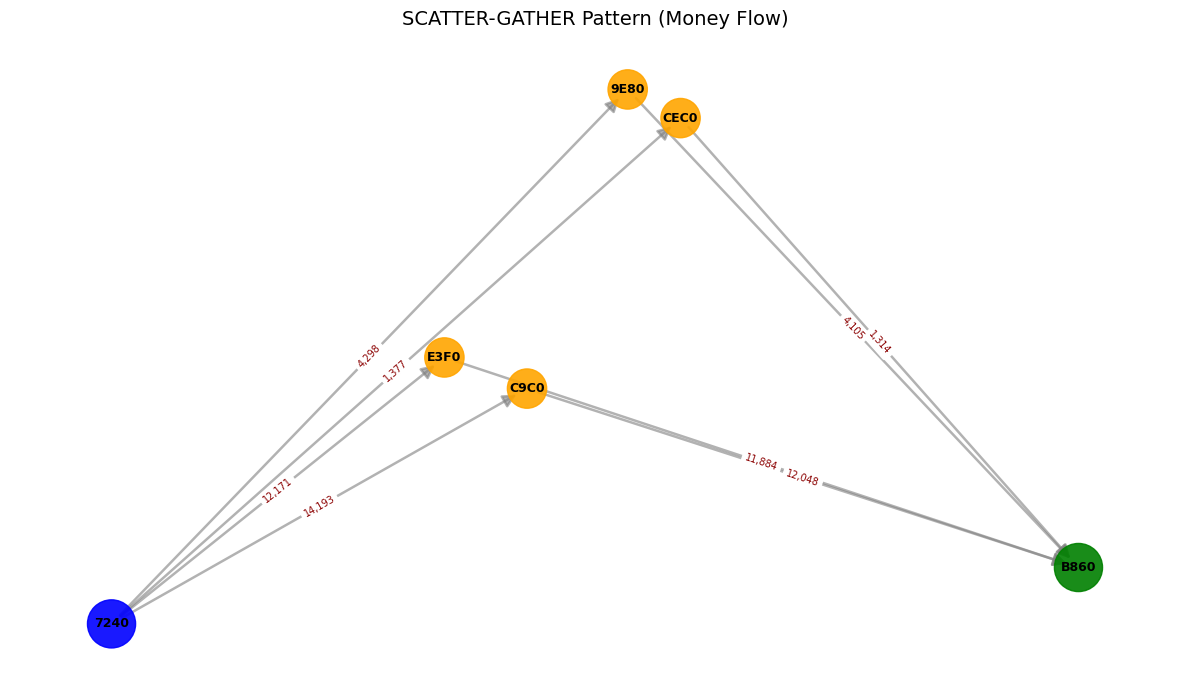


============================== LOẠI GIAN LẬN: RANDOM ==============================


,Timestamp,From_Bank,From_Account,To_Bank,To_Account,Amount_Received,Currency_Received,Amount_Paid,Currency_Paid,Payment_Format,Is_Laundering
0,2022/09/01 03:46,020,820A33D80,0021582,810210610,30537.14,Yuan,30537.14,Yuan,ACH,1
1,2022/09/01 11:00,0021582,810210610,00110104,82C9B2050,5483.26,Canadian Dollar,5483.26,Canadian Dollar,ACH,1
2,2022/09/04 19:39,00110104,82C9B2050,0061358,8240CFD90,4156.19,US Dollar,4156.19,US Dollar,ACH,1


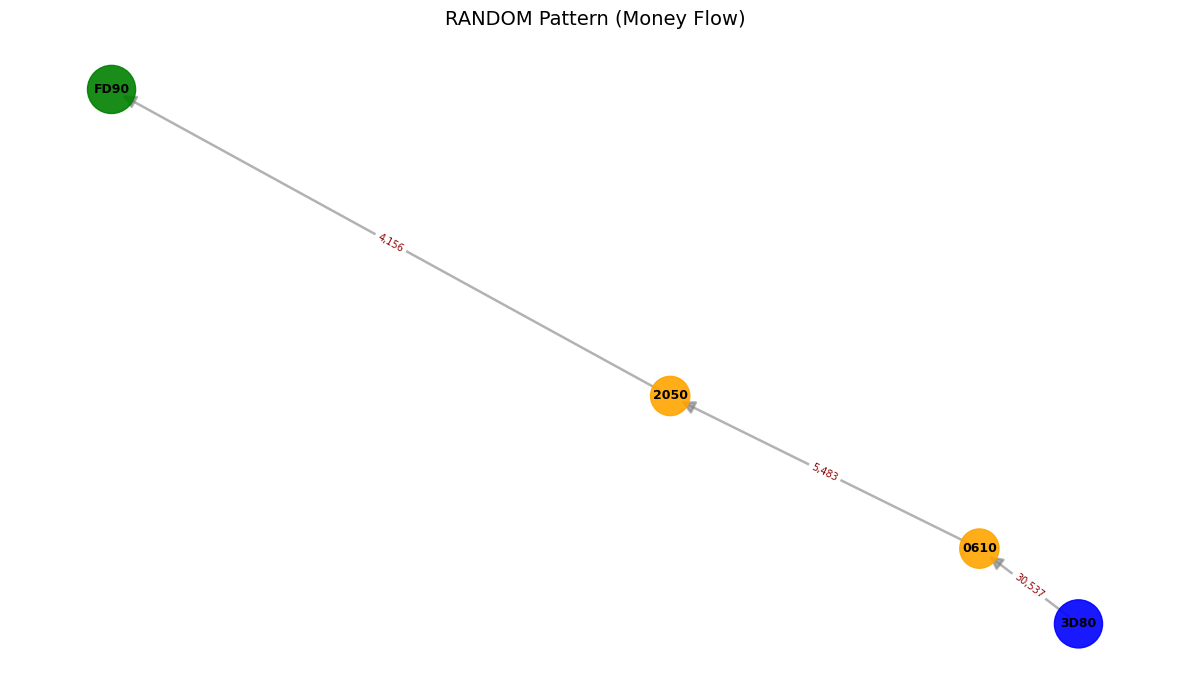

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

for p_type, transactions in examples_per_type.items():
    print(f"\n{'='*30} LOẠI GIAN LẬN: {p_type} {'='*30}")

    temp_df = pd.DataFrame(transactions, columns=column_names)
    display(temp_df)

    G = nx.DiGraph()
    for tx in transactions:
        G.add_edge(tx[2], tx[4], weight=float(tx[7]))

    plt.figure(figsize=(12, 7))

    # =========================
    # 🎯 XÁC ĐỊNH ROLE NODE
    # =========================
    in_deg = dict(G.in_degree())
    out_deg = dict(G.out_degree())

    center_nodes = [n for n in G.nodes() if in_deg[n] > 2 and out_deg[n] > 2]
    senders = [n for n in G.nodes() if out_deg[n] > 0 and in_deg[n] == 0]
    receivers = [n for n in G.nodes() if in_deg[n] > 0 and out_deg[n] == 0]
    others = list(set(G.nodes()) - set(center_nodes) - set(senders) - set(receivers))

    # =========================
    # 🧠 LAYOUT TÙY THEO PATTERN
    # =========================
    pos = {}

    if 'GATHER' in p_type or 'FAN' in p_type:
        # 👉 layout 3 tầng: sender -> center -> receiver
        x_gap = 3

        for i, node in enumerate(senders):
            pos[node] = (-x_gap, i)

        for i, node in enumerate(center_nodes):
            pos[node] = (0, i)

        for i, node in enumerate(receivers):
            pos[node] = (x_gap, i)

        for i, node in enumerate(others):
            pos[node] = (np.random.uniform(-1, 1), np.random.uniform(-1, 1))

    elif 'CYCLE' in p_type:
        pos = nx.circular_layout(G)

    else:
        pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)

    # jitter nhẹ để tránh overlap
    for k in pos:
        pos[k] += np.random.normal(0, 0.05, size=2)

    # =========================
    # 🎨 COLOR + SIZE
    # =========================
    node_colors = []
    node_sizes = []

    for n in G.nodes():
        if n in center_nodes:
            node_colors.append('red')
            node_sizes.append(2000)
        elif n in senders:
            node_colors.append('blue')
            node_sizes.append(1200)
        elif n in receivers:
            node_colors.append('green')
            node_sizes.append(1200)
        else:
            node_colors.append('orange')
            node_sizes.append(800)

    # =========================
    # 🔗 DRAW
    # =========================
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)

    nx.draw_networkx_edges(
        G, pos,
        width=1.8,
        edge_color='gray',
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        alpha=0.6
    )

    # label node (rút gọn)
    labels = {node: node[-4:] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

    # label edge (amount)
    edge_labels = {(u, v): f"{d['weight']:,.0f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='darkred')

    plt.title(f"{p_type} Pattern (Money Flow)", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()